In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import seaborn as sns
from helper import *
from plots import *
import random

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

# Загружаем датасет в память
df = pd.read_csv("diamonds.csv", index_col=0)
df_preprocessed = df.copy()
# Дубликаты
df_preprocessed.drop_duplicates(inplace=True)
# Удаление строк, где x/y/z = 0
df_preprocessed = df_preprocessed[(df_preprocessed[["x", "y", "z"]] != 0).all(axis=1)]
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, "price")
# Разбиваем данные на train, val и test с соотношением 60-20-20
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y, 
    train_size=0.6, 
    val_size=0.2, 
    test_size=0.2, 
    random_state=SEED,
)
X_train_preprocessed = X_train.copy()

categorical_cols = ["cut", "color", "clarity"]
category_orders = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"], # cut
    ["D", "E", "F", "G", "H", "I", "J"], # color
    ["IF", "VVS1", "VVS2", "VS1", "VS2", "SI1", "SI2", "I1"], # clarity
]

preprocessor = Pipeline([    
    ("transformations", ColumnTransformer(
        [("encoder", OrdinalEncoder(categories=category_orders), categorical_cols)],
        remainder="passthrough",  # числовые колонки передаются без изменений
        verbose_feature_names_out=False
    ))
])

# Устанавливаем вывод в формате pandas DataFrame (для sklearn версии 1.0 и выше)
preprocessor.set_output(transform="pandas")
# обучаем и применяем наш пайплайн к тренировочной выборке
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, index=X_train.index)

X_train_preprocessed

,cut,color,clarity,carat,depth,table,x,y,z
15430,2.0,4.0,3.0,1.20,62.0,57.0,6.77,6.81,4.21
52670,4.0,3.0,4.0,0.80,60.1,57.0,6.05,6.02,3.63
43144,2.0,4.0,4.0,0.52,63.5,58.0,5.08,5.09,3.23
32503,2.0,2.0,5.0,0.40,63.3,57.0,4.68,4.73,2.98
33373,2.0,3.0,4.0,0.41,61.7,61.0,4.70,4.74,2.91
...,...,...,...,...,...,...,...,...,...
11882,3.0,4.0,3.0,1.08,62.5,60.0,6.55,6.51,4.08
44832,3.0,1.0,5.0,0.51,61.7,59.0,5.12,5.09,3.15
3687,2.0,5.0,3.0,0.90,62.6,58.0,6.14,6.17,3.85
676,4.0,0.0,2.0,0.54,61.5,55.0,5.25,5.29,3.24


## 6. Построение базовой модели (baseline)
Сейчас наша задача построить базовую модель, от которой мы будем отталкиваться в дальнейшем для применения улучшений. Здесь мы намеренно не трогаем большую часть гиперпараметров моделей и оставляем значения по умолчанию. Подбор этих параметров будет осуществляться позже на финальных стадиях. Мы также не совершали преобразований с данными, направленных на улучшение, поскольку пока что нам не с чем сравнивать наш результат. 

In [4]:
# применяем уже обученный пайплайн к тестовой выборке.
# Очень важно: здесь уже вызываем transform без fit, чтобы не допустить обучения на тестовых данных
X_val_preprocessed = preprocessor.transform(X_val)

In [5]:
X_val_preprocessed

,cut,color,clarity,carat,depth,table,x,y,z
25371,4.0,2.0,2.0,0.28,61.4,57.0,4.20,4.24,2.59
2303,1.0,1.0,4.0,0.74,63.9,54.0,5.77,5.81,3.70
13476,3.0,3.0,6.0,1.22,60.2,58.0,6.92,6.90,4.16
43791,2.0,2.0,5.0,0.56,63.2,56.0,5.29,5.24,3.33
45413,4.0,3.0,3.0,0.51,61.7,56.0,5.10,5.20,3.18
...,...,...,...,...,...,...,...,...,...
50388,1.0,3.0,5.0,0.71,62.3,56.0,5.68,5.72,3.55
41281,2.0,1.0,0.0,0.31,61.5,59.0,4.34,4.37,2.68
40734,4.0,2.0,6.0,0.54,61.2,56.0,5.27,5.28,3.23
2145,4.0,1.0,1.0,0.52,61.8,55.0,5.20,5.19,3.21


In [6]:
X_val_preprocessed.info()

<class 'pandas.DataFrame'>
Index: 10755 entries, 25371 to 45149
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cut      10755 non-null  float64
 1   color    10755 non-null  float64
 2   clarity  10755 non-null  float64
 3   carat    10755 non-null  float64
 4   depth    10755 non-null  float64
 5   table    10755 non-null  float64
 6   x        10755 non-null  float64
 7   y        10755 non-null  float64
 8   z        10755 non-null  float64
dtypes: float64(9)
memory usage: 840.2 KB


In [7]:
X_val_preprocessed.isnull().sum()

cut        0
color      0
clarity    0
carat      0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

In [8]:
feature_names = X_val_preprocessed.columns.to_list()

### 6.1 Dummy Classifier
Для начала попробуем использовать глупый классификатор, который всегда предсказывает только самый частый класс и посмотреть на значение метрик. Это даст нам понимание, от какого нижнего порога метрик нам отталкиваться и с чем сравнивать наши модели.

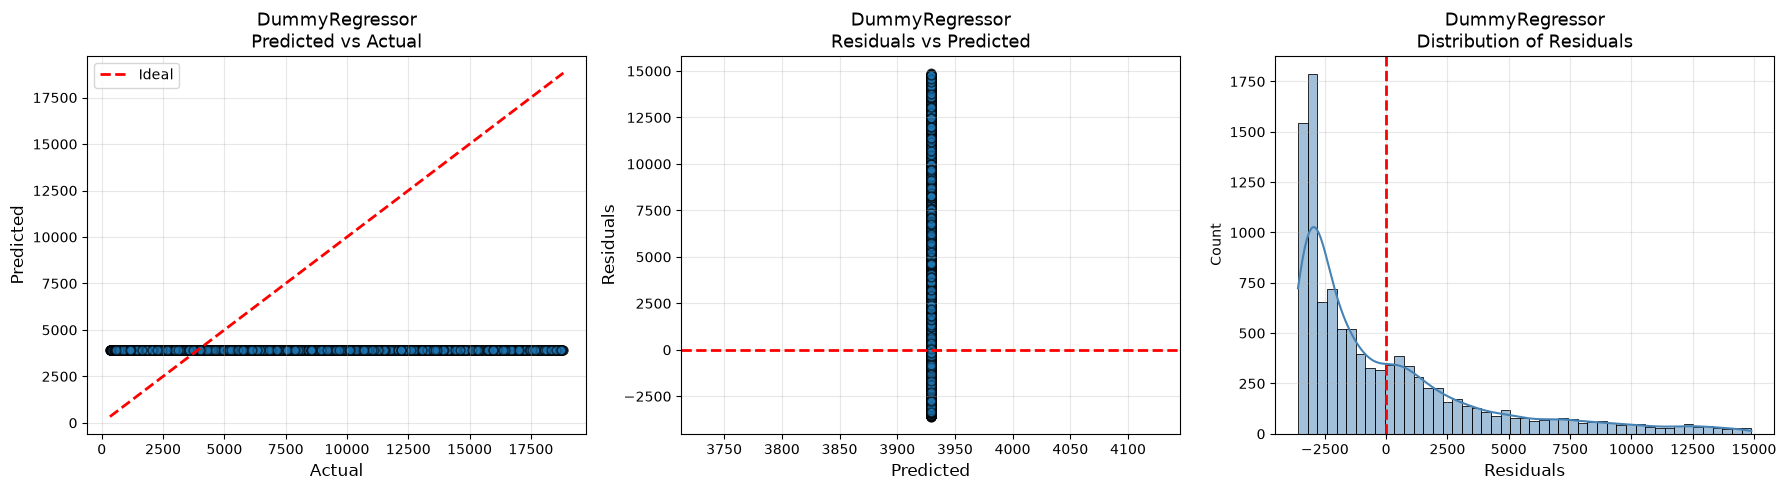

 Regression Report: DummyRegressor
MAE   : 3038.2705
MSE   : 15960929.7594
RMSE  : 3995.1132
R²    : -0.0000
MAPE  : 187.61%
MedAE : 2782.9814


In [10]:
# Задаем и обучаем модель
dummy_classifier = DummyRegressor(strategy="mean")
dummy_classifier.fit(X_train_preprocessed, y_train)

# Получаем предсказания
y_pred = dummy_classifier.predict(X_val_preprocessed)

# Считаем метрики для модели и выводим графики
dummy_classifier_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="DummyRegressor"
)

Сейчас модель просто угадывает среднее и не несёт никакой предсказательной силы.

### 6.2 Логистическая регрессия

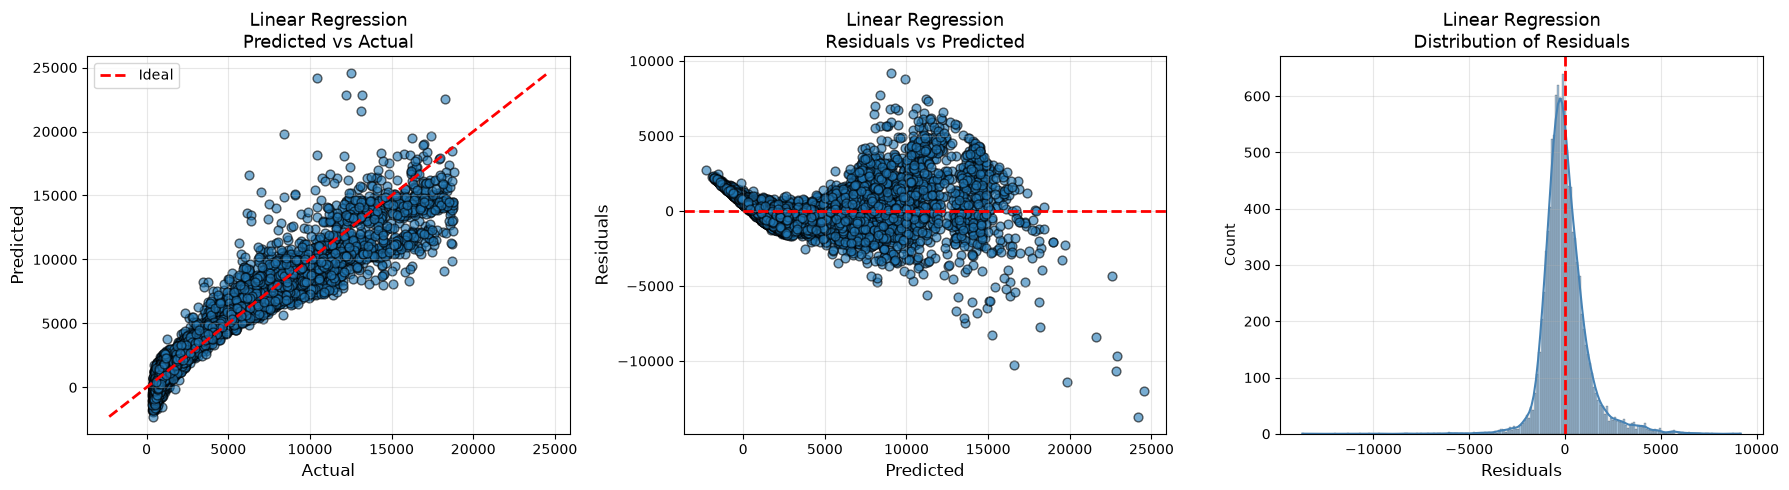

 Regression Report: Linear Regression
MAE   : 802.9022
MSE   : 1451520.3081
RMSE  : 1204.7906
R²    : 0.9091
MAPE  : 43.01%
MedAE : 574.6668


In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_preprocessed, y_train)

y_pred = lin_reg.predict(X_val_preprocessed)

lin_reg_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="Linear Regression"
)

Неплохие результаты для линейной регресии с базовыми признаками: 
- Predicted vs Actual: Точки хорошо ложатся вдоль идеальной линии
- Residuals vs Predicted: Остатки в целом центрированы около нуля, но разброс ошибок растёт с увеличением предсказанной цены.
- Distribution of Residuals: Распределение ошибок близко к нормальному

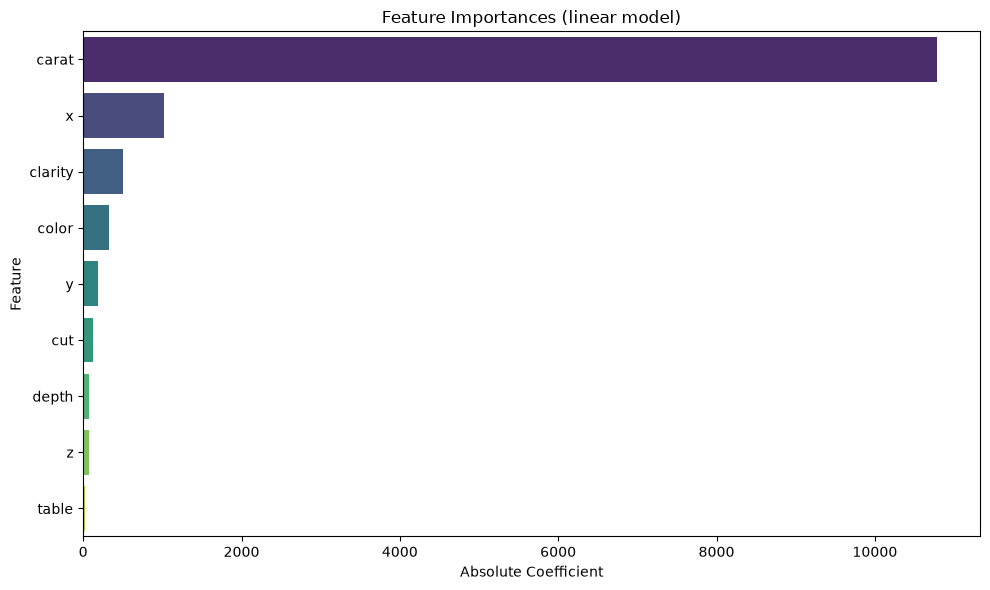

,Feature,Importance
3,carat,10788.384482
6,x,1026.301596
2,clarity,498.508412
1,color,320.955262
7,y,186.918167
0,cut,120.735899
4,depth,78.089355
8,z,74.984570
5,table,25.794991


In [13]:
# Построим гистограмму важностей для каждой фичи
plot_feature_importance(lin_reg, feature_names)

По важности признаков на первом месте оказался вес в каратах

### 6.3 Дерево решений

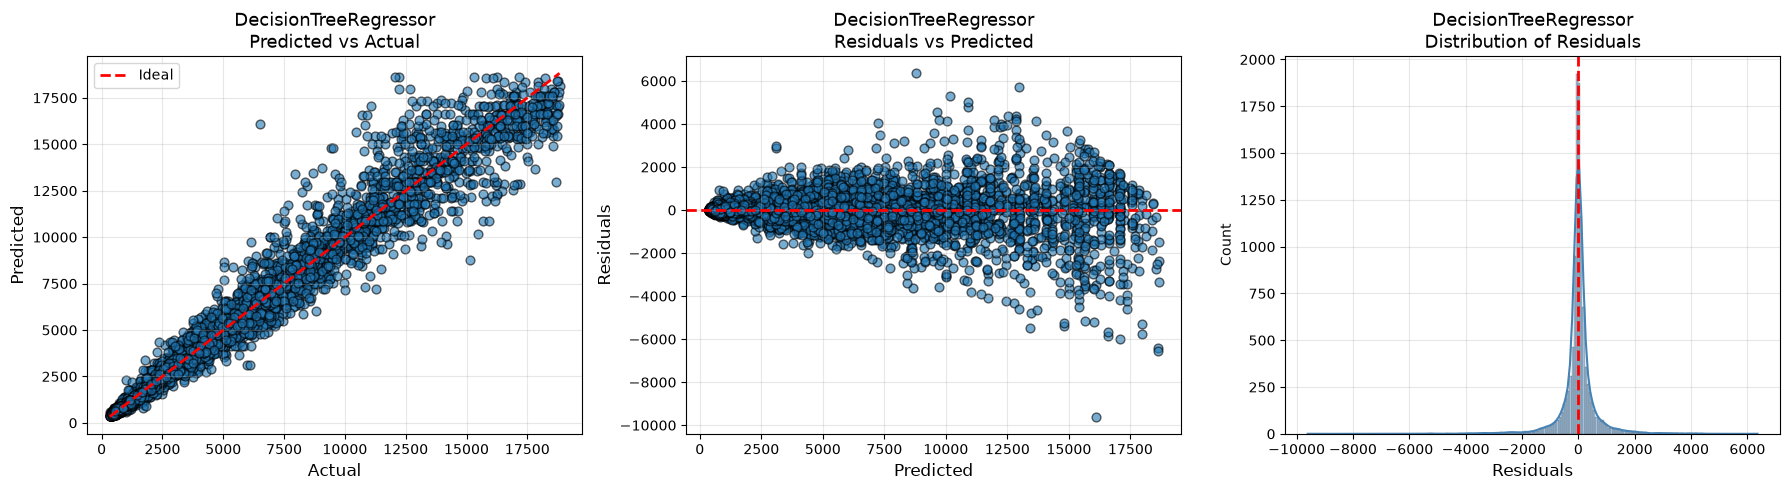

 Regression Report: DecisionTreeRegressor
MAE   : 333.8730
MSE   : 448635.0502
RMSE  : 669.8022
R²    : 0.9719
MAPE  : 8.61%
MedAE : 128.9224


In [21]:
decision_tree = DecisionTreeRegressor(random_state=SEED, max_depth=12)
decision_tree.fit(X_train_preprocessed, y_train)

y_pred = decision_tree.predict(X_val_preprocessed)

decision_tree_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="DecisionTreeRegressor"
)

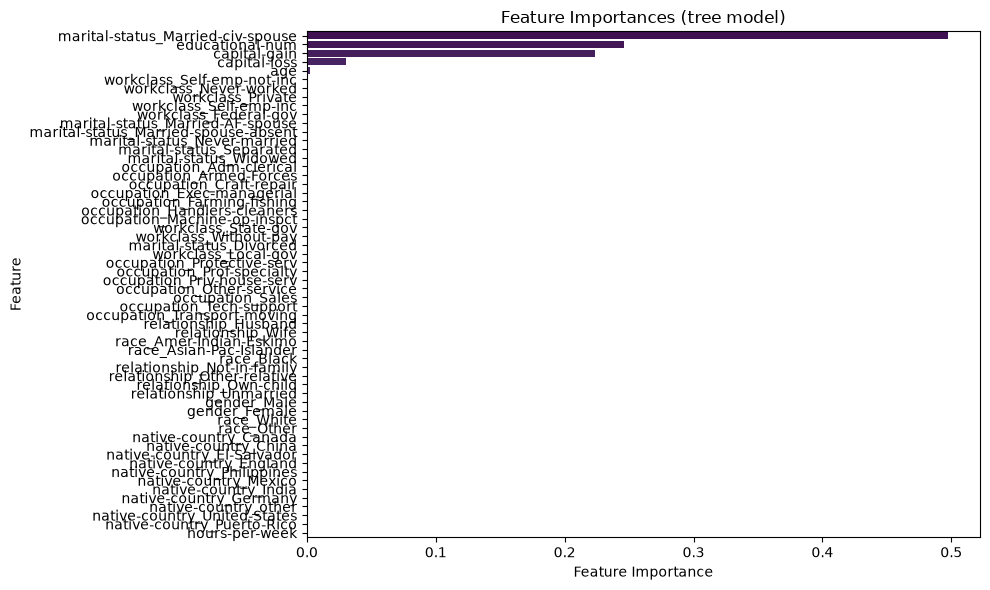

,Feature,Importance
10,marital-status_Married-civ-spouse,0.497413
54,educational-num,0.246319
55,capital-gain,0.223880
56,capital-loss,0.030235
53,age,0.002154
5,workclass_Self-emp-not-inc,0.000000
2,workclass_Never-worked,0.000000
3,workclass_Private,0.000000
4,workclass_Self-emp-inc,0.000000
0,workclass_Federal-gov,0.000000


In [28]:
plot_feature_importance(decision_tree, feature_names)

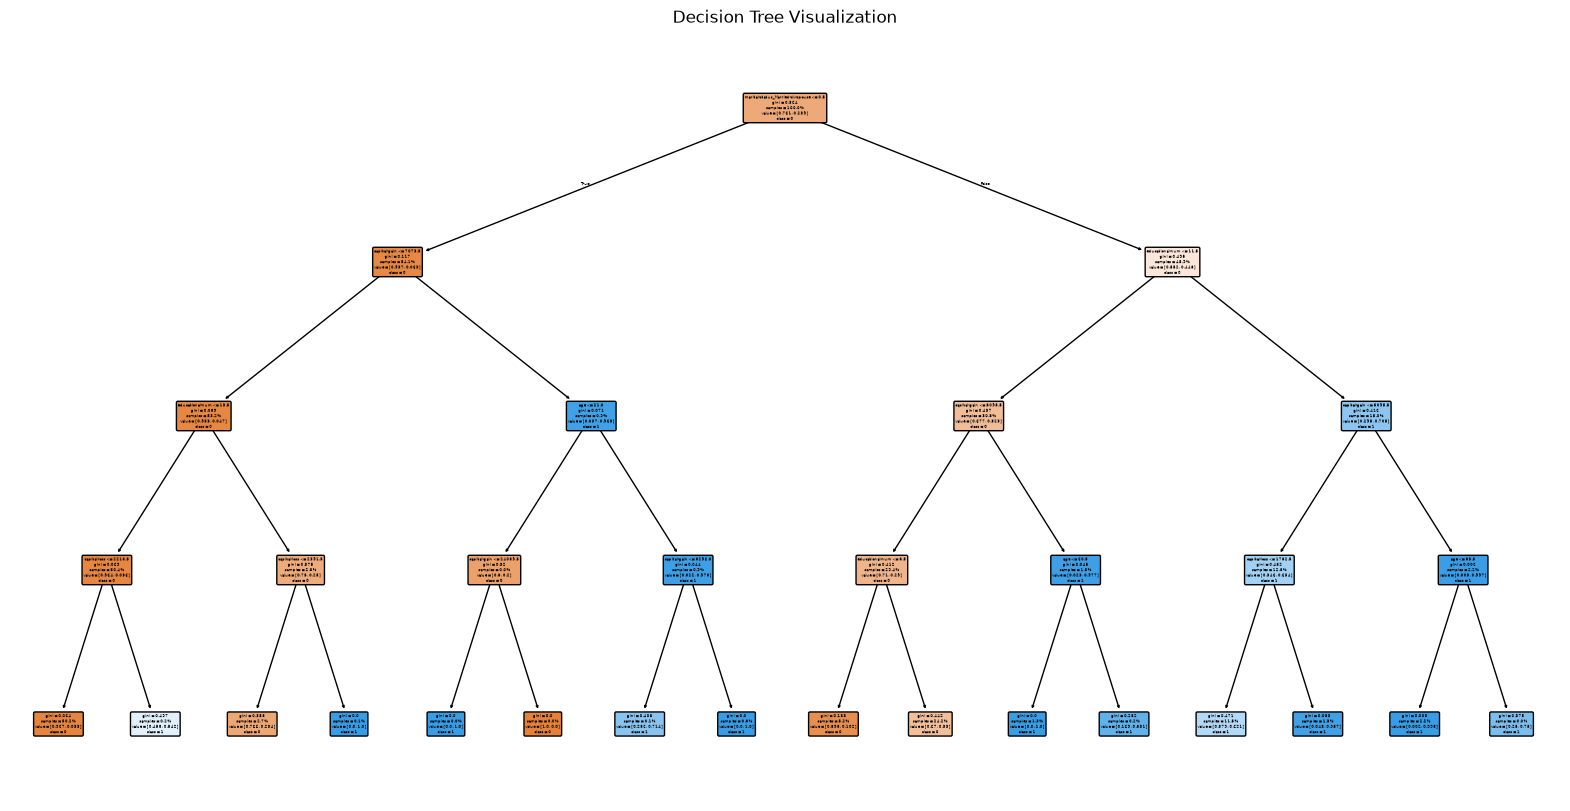

In [29]:
# Визуализируем наше дерево решений
visualize_decision_tree(decision_tree, feature_names, class_names=['0', '1'])

Оранжевым цветом изображены вершины с классом 0, синим - с классом 1. Значение value показывает, какая доля семплов в вершине относится к 0 и 1 классам соответственно. Samples показывает, какая доля всех семплов оказалась в этой вершине.

### 6.4 Случайный лес

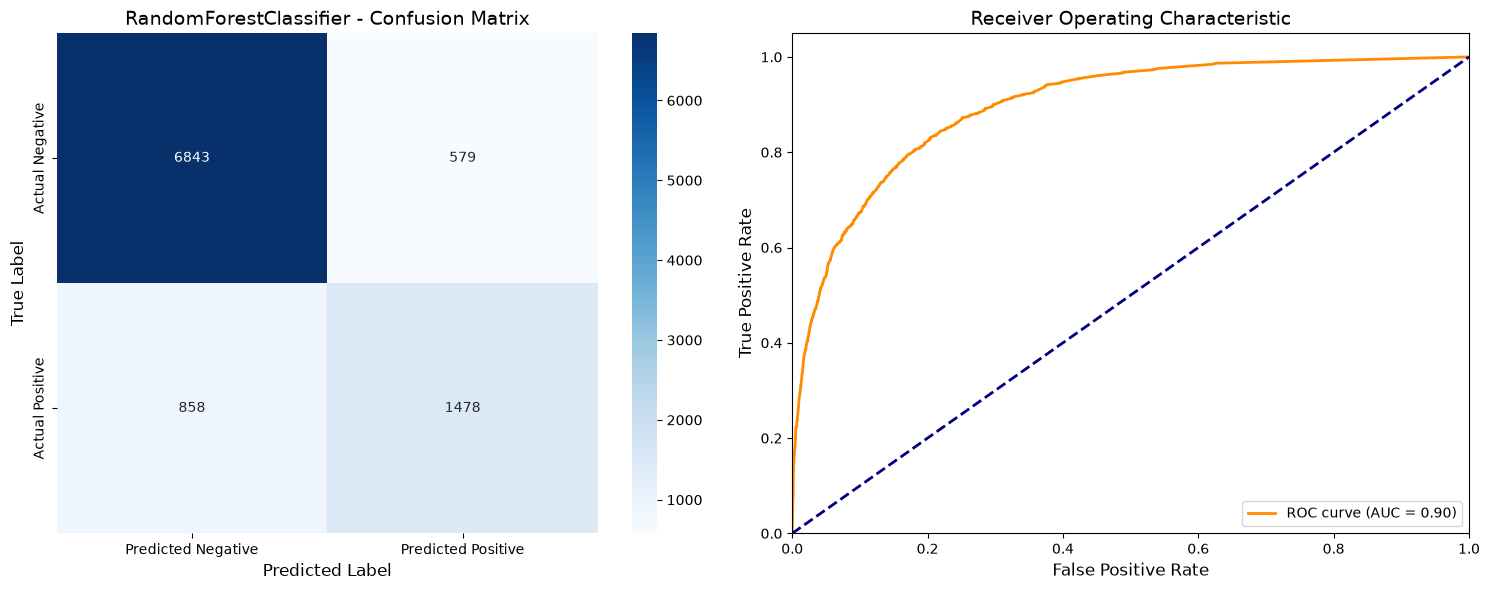


             RANDOMFORESTCLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8963
 F1 Score 0.7889
Precision 0.8036
   Recall 0.7773
 Accuracy 0.8527


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.718522 0.632705
Negative   0.888586 0.921989



In [30]:
# Train your model
random_forest = RandomForestClassifier(random_state=SEED)
random_forest.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = random_forest.predict(X_val_preprocessed)
y_probs = random_forest.predict_proba(X_val_preprocessed)[:, 1]  # For ROC curve

# Evaluate
random_forest_metrics = evaluate_classification(
    y_test=y_val,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="RandomForestClassifier"
)

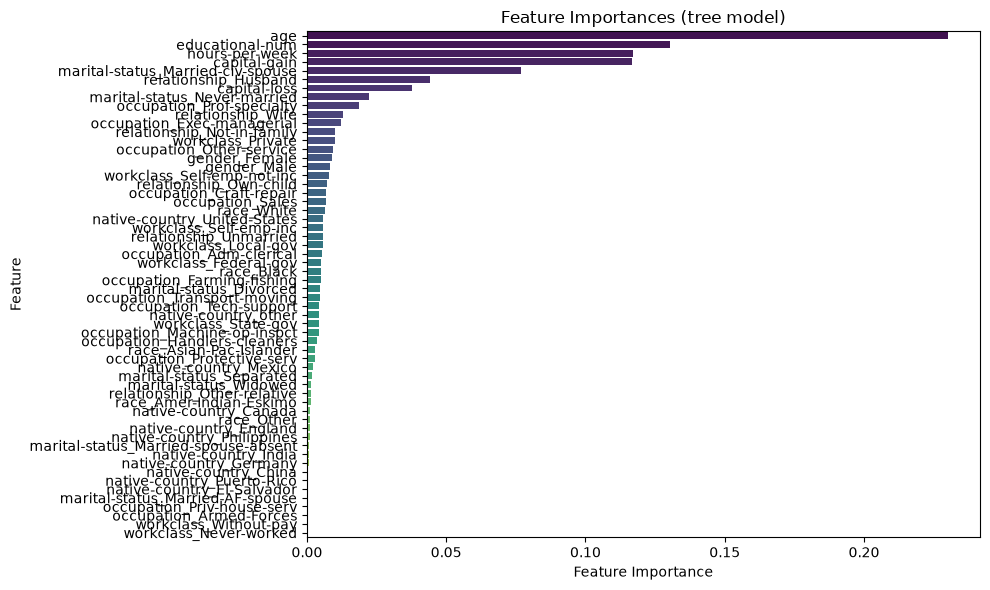

,Feature,Importance
53,age,0.230131
54,educational-num,0.130424
57,hours-per-week,0.117212
55,capital-gain,0.116584
10,marital-status_Married-civ-spouse,0.076934
29,relationship_Husband,0.044165
56,capital-loss,0.037699
12,marital-status_Never-married,0.022211
24,occupation_Prof-specialty,0.018547
34,relationship_Wife,0.013088


In [31]:
plot_feature_importance(random_forest, feature_names)

Заметно использование более "говорящих" фичей по типу возраста, образования, дохода от инвестиций, часы в неделю и т.д.

### 6.5 Градиентный бустинг

[LightGBM] [Info] Number of positive: 7009, number of negative: 22265
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 451
[LightGBM] [Info] Number of data points in the train set: 29274, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239427 -> initscore=-1.155821
[LightGBM] [Info] Start training from score -1.155821


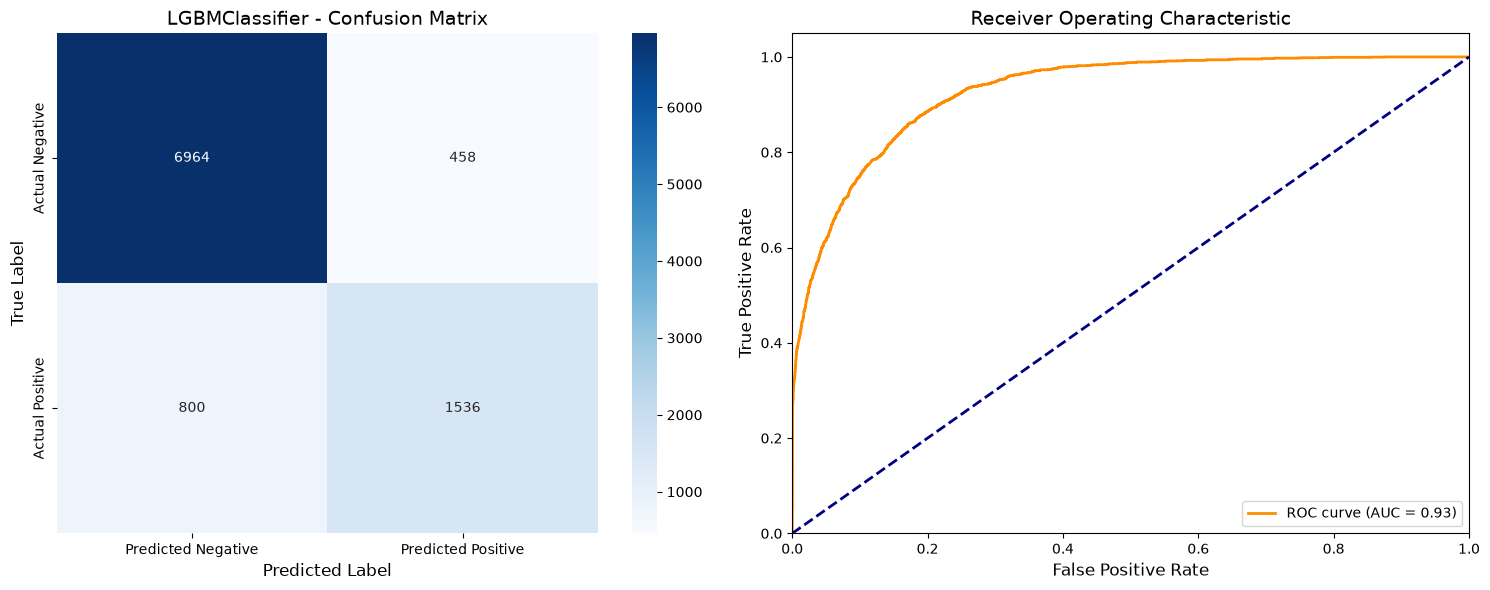


                 LGBMCLASSIFIER EVALUATION                  

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9271
 F1 Score 0.8133
Precision 0.8336
   Recall 0.7979
 Accuracy 0.8711


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.770311 0.657534
Negative   0.896960 0.938292



In [32]:
# Train your model
lgbm = LGBMClassifier(random_state=SEED)
lgbm.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = lgbm.predict(X_val_preprocessed)
y_probs = lgbm.predict_proba(X_val_preprocessed)[:, 1]  # For ROC curve

# Evaluate
lgbm_metrics = evaluate_classification(
    y_test=y_val,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="LGBMClassifier"
)

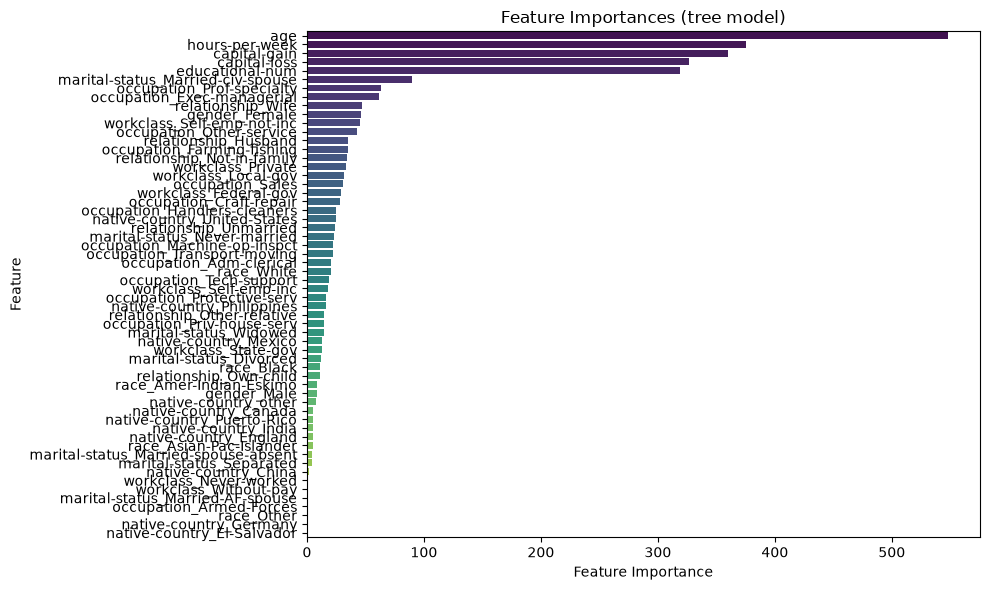

,Feature,Importance
53,age,548
57,hours-per-week,375
55,capital-gain,360
56,capital-loss,327
54,educational-num,319
10,marital-status_Married-civ-spouse,90
24,occupation_Prof-specialty,63
18,occupation_Exec-managerial,62
34,relationship_Wife,47
40,gender_Female,46


In [33]:
plot_feature_importance(lgbm, feature_names)

Здесь мы видим сильную разницу по сравнению с другими моделями: теперь в качестве самых важных фич выступают уже age, capital-loss, capital-gain, hours-per-week и educational-num - что в принципе логично и ожидаемо. Признаки, связанные с полом и социальной ролью сместились ниже. Также по сравнению с Random Forest теперь учитывается не только capital-gain, но и capital-loss.

Бустинг лучше справился с определением наиболее важных фичей и нахождением нелинейных закономерностей.

### 6.6 Финальное сравнение метрик

In [34]:
final_metrics = {
    'dummy_classifier': dummy_classifier_metrics,
    'log_reg': log_reg_metrics,
    'decision_tree': decision_tree_metrics,
    'random_forest': random_forest_metrics,
    'lgbm': lgbm_metrics
}

result = pd.DataFrame(final_metrics.values(), index=final_metrics.keys())

In [35]:
result

,ROC AUC,F1 Score,Precision,Recall,Accuracy
dummy_classifier,0.500000,0.432014,0.380303,0.500000,0.760607
log_reg,0.901182,0.781334,0.809207,0.762636,0.852224
decision_tree,0.864610,0.761219,0.797768,0.739607,0.842181
random_forest,0.896280,0.788934,0.803554,0.777347,0.852736
lgbm,0.927086,0.813315,0.833636,0.797913,0.871080


<Axes: >

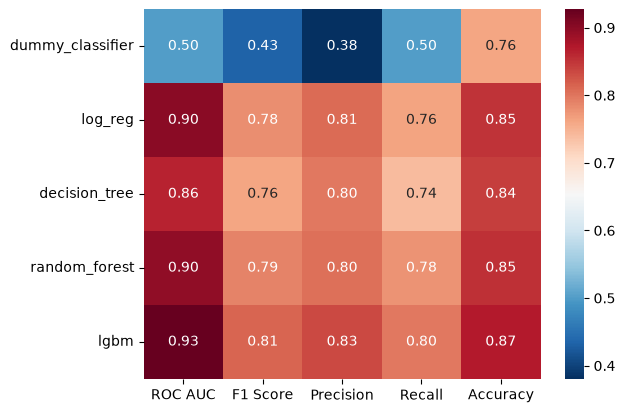

In [36]:
sns.heatmap(result, cmap='RdBu_r', annot=True, fmt=".2f")